# Introduction

Text data, with its vast and unstructured nature, presents substantial challenges in extracting meaningful insights and identifying underlying patterns. The 20 Newsgroups dataset, which includes a diverse array of newsgroup posts across various topics, exemplifies this complexity. Manually categorizing such extensive and varied content is both time-consuming and impractical.

This project leverages unsupervised learning techniques to address these challenges by automatically discovering and categorizing topics within the dataset. Initially, clustering algorithm is employed to group similar texts and identify potential topics. Following this, Latent Dirichlet Allocation (LDA) is utilized to extract distinct and interpretable topics from the data. By visualizing these topics and their interrelationships, the analysis provides a structured understanding of the dataset’s thematic structure, which is invaluable for applications such as content recommendation, information retrieval, and text classification.

In [10]:
# Import necessary libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import os
import sys
import re
import string
import nltk
from nltk.corpus import stopwords
import spacy
from collections import Counter
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import gensim
import gensim.corpora as corpora
from gensim.models import CoherenceModel
import pyLDAvis
import pyLDAvis.gensim

# Prepare Dataset

The 20 Newsgroups dataset comprises approximately 20,000 newsgroup documents, divided into 20 distinct categories. Each category, or newsgroup, represents a specific topic, such as 'comp.graphics', 'rec.autos', or 'sci.space'.

The input directory contains 20 folders, each corresponding to a different category. Inside each folder, there are roughly 1,000 text files. The first step in processing this dataset involves extracting the text data from these files and assigning numerical labels to represent their respective categories.


In [11]:
data_dir = r'../input/20-newsgroup-original/20_newsgroup/20_newsgroup/'
print('Folders in the Dataset: ')
!ls {data_dir}]

Folders in the Dataset: 
ls: cannot access '../input/20-newsgroup-original/20_newsgroup/20_newsgroup/]': No such file or directory


In [12]:
# Extracting files from folders

texts = [] # List to store text from each file
labels = [] # List to store each files category(folder name)
labels_index = {}  # Dictionary to map category names to numeric labels

# Loop through each folder in the dataset directory
for folder_name in sorted(os.listdir(data_dir)):
    folder_path = os.path.join(data_dir, folder_name)
    
    if os.path.isdir(folder_path):
        # Store new label ID for each folder (category)
        label_id = len(labels_index) 
        labels_index[folder_name] = label_id  
        
        # Loop through each file in the folder
        for fname in sorted(os.listdir(folder_path)):
            file_path = os.path.join(folder_path, fname)
            
            if os.path.isfile(file_path):
                with open(file_path, encoding='latin-1') as f:
                    text = f.read()
                    
                    # Optionally skip the header if present
                    i = text.find('\n\n')  
                    if i != -1:
                        text = text[i:]
                    
                    texts.append(text.strip())  # Add text content to the list
                    labels.append(label_id)  # Add corresponding label ID


print(f'Number of texts: {len(texts)} \n')
print(f'Number of labels: {len(labels)} \n')
print(f'Categories to Index Mapping: \n{labels_index}')

Number of texts: 19997 

Number of labels: 19997 

Categories to Index Mapping: 
{'alt.atheism': 0, 'comp.graphics': 1, 'comp.os.ms-windows.misc': 2, 'comp.sys.ibm.pc.hardware': 3, 'comp.sys.mac.hardware': 4, 'comp.windows.x': 5, 'misc.forsale': 6, 'rec.autos': 7, 'rec.motorcycles': 8, 'rec.sport.baseball': 9, 'rec.sport.hockey': 10, 'sci.crypt': 11, 'sci.electronics': 12, 'sci.med': 13, 'sci.space': 14, 'soc.religion.christian': 15, 'talk.politics.guns': 16, 'talk.politics.mideast': 17, 'talk.politics.misc': 18, 'talk.religion.misc': 19}


In [13]:
# Creating a dataframe
df = pd.DataFrame({
    'text': texts,
    'label': labels
})
print(df)

                                                    text  label
0      Archive-name: atheism/resources\nAlt-atheism-a...      0
1      Archive-name: atheism/introduction\nAlt-atheis...      0
2      In article <65974@mimsy.umd.edu>\nmangoe@cs.um...      0
3      dmn@kepler.unh.edu (...until kings become phil...      0
4      In article <N4HY.93Apr5120934@harder.ccr-p.ida...      0
...                                                  ...    ...
19992  In article <930426.140835.4f1.rusnews.w165w@ma...     19
19993  In article <1993Apr27.073723.18577@csis.dit.cs...     19
19994  In article <1rc1f3INN7rl@emx.cc.utexas.edu> \n...     19
19995  In article <1993Apr26.231845.13843@digi.lonest...     19
19996  In article <C64H4w.BFH@darkside.osrhe.uoknor.e...     19

[19997 rows x 2 columns]


In [14]:
# shuffling the dataset
shuffled_df = df.sample(frac=1, random_state = 42).reset_index(drop=True)
print(shuffled_df)

                                                    text  label
0      In article <1993Apr16.185823.6310@news.columbi...     10
1      Hi-\nDoes anyone out there know how I would ge...      4
2      mreamy@rock.concert.net (Michael G Reamy -- Su...      3
3      Hi,\n\nI just inherited an NCR 1204 external f...      3
4      In article <1993May15.021746.9527@seas.smu.edu...     17
...                                                  ...    ...
19992  In article <16695@rand.org>, jim@rand.org (Jim...     11
19993  Yesterday I read an article from someone who w...     11
19994  I want to be able to send a Pixmap from one cl...      5
19995  kv07@IASTATE.EDU (Warren Vonroeschlaub) writes...      0
19996  In article <May.7.01.09.04.1993.14501@athos.ru...     15

[19997 rows x 2 columns]


# Preprocessing

In [17]:
def preprocess(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www.\S+', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    text = ' '.join(word for word in text.split() if word not in stop_words)
    
    # Remove very large or very short words
    text = re.sub(r'\b\w{1,2}\b|\b\w{13,}\b', '', text)
    
    # Remove digits
    text = re.sub(r'\d+', '', text)
    
    # Remove specific frequent words
    frequent_words = set(['article', 'email', 'write', 'writes', 'wrote', 'subject', 're'])
    text = ' '.join(word for word in text.split() if word.lower() not in frequent_words)
    
    return text
    
    

In [18]:
# Apply preprocessing function to text
shuffled_df['clean_text'] = shuffled_df['text'].apply(lambda text: preprocess(text))
shuffled_df.head()

,text,label,clean_text
0,In article <1993Apr16.185823.6310@news.columbi...,10,gary dare keenans cocoach number one team cana...
1,Hi-\nDoes anyone out there know how I would ge...,4,anyone know would get started writing device d...
2,mreamy@rock.concert.net (Michael G Reamy -- Su...,3,michael reamy support said nanao ti best monit...
3,"Hi,\n\nI just inherited an NCR 1204 external f...",3,inherited ncr external floppy thing every port...
4,In article <1993May15.021746.9527@seas.smu.edu...,17,paul thompson schreiber nancy najarian huddled...


In [19]:
# Comparing original and cleaned text
print ("Original Text:")
print (shuffled_df['text'][0])

print('\n\n\n')

print ("Cleaned Text:")
print (shuffled_df['clean_text'][0])

Original Text:
In article <1993Apr16.185823.6310@news.columbia.edu> gld@cunixb.cc.columbia.edu (Gary L Dare) writes:
>
>Interestingly, Keenan's co-coach (or is it his "Number One"?) on Team
>Canada at the World Championships is Roger Neilsen.  
>

But ultimately their hockey philosophies are like night and day...
Keenan believes in pressuring the opposition and taking the
initiative (within the limits of his system)...while Roger
has a reactive hockey philosophy...which is why Messier will
be able to and has played for Keenan, but thought Roger's way
was a sure loser.

>It'd be interesting if the Rangers call in the balance of Neilsen's
>contract to be Keenan's assistant ...  Roger did do a very good job
>with the mediocre players, just as he handled the Cinderella Canucks
>of 10 years ago ... but his mistake was playing the Rangers like those
>Canucks last May ...
>

Roger is a great assistant coach...but considering what must be bad
blood between Nielson and Messier, it would be a mi

## Visualizing Word Frequencies
To gain insights into the most common words in the dataset, we plot a bar graph showing the frequency of the top 50 words after preprocessing. This helps us understand the dominant terms in the dataset and identify any potential noise.


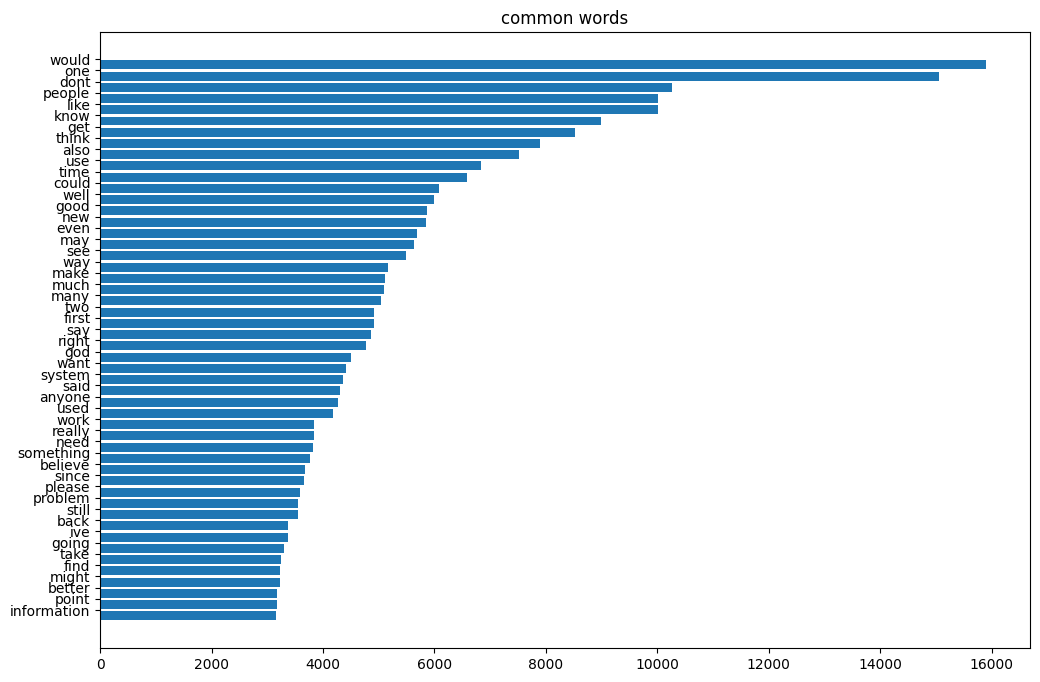

In [20]:
# Function to plot Bar graph for most common words
def wordBarGraph(df,column,title):
    # split words into list
    topic_words = [ z.lower() for y in
                       [ x.split() for x in df[column] if isinstance(x, str)]
                       for z in y]
    
    # count occurence of word
    word_count_dict = dict(Counter(topic_words))
    # sort words by their occurrence 
    popular_words = sorted(word_count_dict, key = word_count_dict.get, reverse = True)
    
    plt.figure(figsize=(12, 8))
    popular_words_nonstop = [w for w in popular_words if w not in stopwords.words("english")]
    plt.barh(range(50), [word_count_dict[w] for w in reversed(popular_words_nonstop[0:50])])
    plt.yticks([x + 0.5 for x in range(50)], reversed(popular_words_nonstop[0:50]))
    plt.title(title)
    plt.show()
    
wordBarGraph(shuffled_df, 'clean_text', 'common words')

## Word Count Distribution
I analyzed the distribution of word counts in the cleaned text data. A histogram is plotted to visualize the frequency of different word counts, which helps us understand the text length distribution in the dataset.


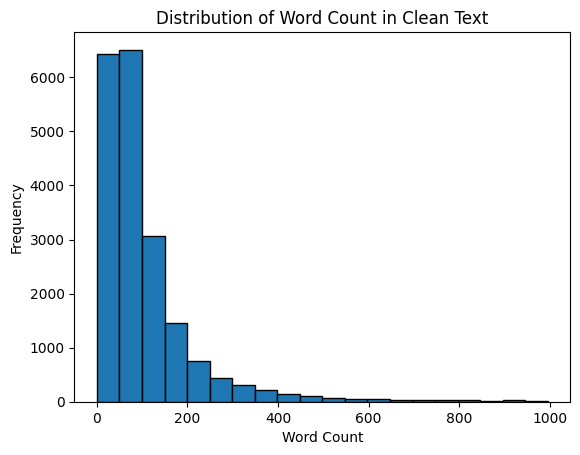

In [21]:
# Number of words in each text
shuffled_df['word_count'] = shuffled_df['clean_text'].apply(lambda x: len(x.split()))

filtered_df = shuffled_df[shuffled_df['word_count'] < 1000]

# Plot histogram of text lengths
plt.hist(filtered_df['word_count'], bins=20, edgecolor='black')
plt.title('Distribution of Word Count in Clean Text')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

Most of the text lies into word length of 0-200.

# TF-IDF Vectorization
In this step, the cleaned text is converted into numerical features using TF-IDF vectorization. This transformation creates a matrix representing the importance of terms within the text. Parameters such as `max_df`, `min_df`, and `ngram_range` are tuned to capture relevant features for further analysis.



In [23]:
# Initialize the TF-IDF Vectorizer
vectorizer = TfidfVectorizer(lowercase=True,
                             max_features=200, #selecting top 200 features by term frequency
                             max_df=0.7, # Ignore terms that appear in more than 70% of the documents
                             min_df=4,  # Ignore terms that appear in fewer than 4 documents
                             ngram_range = (1,3), # Consider unigrams, bigrams, and trigrams
                             stop_words = "english") # Remove common English stop words


# Fit and transform the clean_text to obtain TF-IDF features
tfidf_matrix = vectorizer.fit_transform(shuffled_df['clean_text'])


# Convert the TF-IDF matrix to a DataFrame for easier manipulation
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df.head()

,able,actually,ago,agree,answer,ask,available,away,bad,based,...,window,windows,word,work,world,wrong,year,years,yes,youre
0,0.273135,0.000000,0.289668,0.0,0.0,0.0,0.000000,0.000000,0.279870,0.000000,...,0.0,0.000000,0.0,0.000000,0.262611,0.000000,0.000000,0.244089,0.0,0.0
1,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2,0.000000,0.091733,0.000000,0.0,0.0,0.0,0.099727,0.000000,0.000000,0.107651,...,0.0,0.518681,0.0,0.000000,0.000000,0.098135,0.282361,0.000000,0.0,0.0
3,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
4,0.000000,0.000000,0.088220,0.0,0.0,0.0,0.000000,0.042706,0.042618,0.000000,...,0.0,0.000000,0.0,0.034719,0.159960,0.041681,0.039976,0.111509,0.0,0.0


# Clustering
I applied K-Means clustering to the TF-IDF matrix to group the text documents into clusters based on their content. Each cluster represents a collection of documents with similar themes. The top terms in each cluster provide insights into the common topics within each group.


In [25]:
# Implement K Means CLustering
model = KMeans(n_clusters=10, init="k-means++", max_iter=100, n_init=1)
model.fit(tfidf_matrix)

KMeans(max_iter=100, n_clusters=10, n_init=1)

In [26]:
# Get indices of cluster centers
centroids = model.cluster_centers_.argsort()[:, ::-1]

# Get the feature names
terms = vectorizer.get_feature_names_out()

i = 1
# Loop through each cluster and print the top 10 terms
for cluster in centroids:
    print (f"Cluster {i}")
    
    for keyword in cluster[0:10]:
        print (terms[keyword])
        
    print ("")
    i=i+1

Cluster 1
jesus
god
christian
people
say
believe
dont
think
life
john

Cluster 2
god
believe
people
say
think
know
dont
christian
life
jesus

Cluster 3
like
time
university
information
internet
know
space
make
way
used

Cluster 4
new
use
key
chip
used
like
using
know
work
need

Cluster 5
drive
hard
disk
thanks
software
problem
use
new
like
card

Cluster 6
game
team
games
year
think
time
like
dont
best
good

Cluster 7
people
government
like
dont
think
right
said
believe
time
way

Cluster 8
dont
know
like
think
good
say
really
dont know
time
want

Cluster 9
thanks
windows
card
file
know
dos
program
help
files
like

Cluster 10
car
like
good
new
dont
price
know
think
ive
power



The top terms in each cluster reflect the common themes within the clusters. For example, one cluster contains terms like 'god', 'jesus', and 'believe', indicating that the texts in this cluster are likely related to religious topics. This analysis shows that the words in each cluster are related and that each cluster represents a distinct theme different from the others.

## Dimensionality Reduction with PCA
To visualize the clustering results, I reduce the dimensionality of the TF-IDF matrix using Principal Component Analysis (PCA). This allows us to plot the clusters in a 2D scatter plot, making it easier to interpret the clustering outcomes.


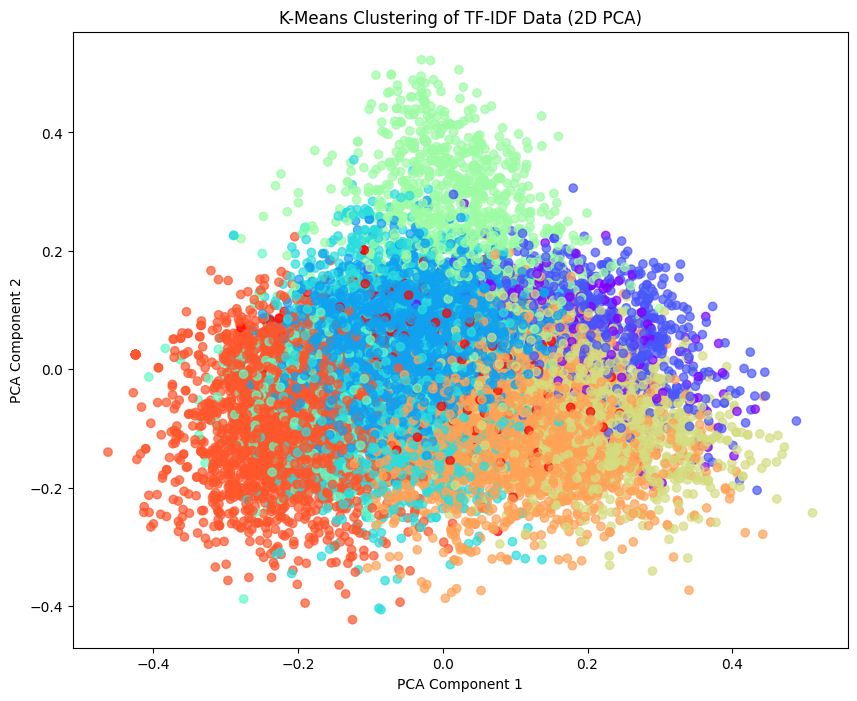

In [27]:
# Reduce the dimensionality of the TF-IDF matrix to 2 dimensions using PCA
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(tfidf_matrix.toarray())

# Plot the reduced data
plt.figure(figsize=(10, 8))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=model.labels_, cmap='rainbow', alpha=0.7)
plt.title('K-Means Clustering of TF-IDF Data (2D PCA)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


# LDA Implementation

## Lemmatization 

In [28]:
# Load the spaCy model
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
allowed_postags=["NOUN", "ADJ", "VERB", "ADV"]

# implement Lemmatization
def lemmatize_text(text):
    doc = nlp(text)
    lemmatized_text = ' '.join([token.lemma_ for token in doc if token.pos_ in allowed_postags])
    return lemmatized_text



In [ ]:
shuffled_df['lemma_text'] = shuffled_df['clean_text'].apply(lambda text: lemmatize_text(text))
shuffled_df.head()

## Tokenization and Bag-of-Words Representation

In this step, I tokenize the lemmatized text into individual words and create a dictionary mapping each unique word to a unique ID using the gensim library. The text is then converted into a Bag-of-Words (BoW) representation, where each document is represented as a list of tuples. Each tuple contains a word's ID and its corresponding frequency in the document. This sparse representation of text data is foundational for many NLP tasks, including topic modeling and text classification.

In [ ]:
# Tokenize text into words
shuffled_df['text_tokens'] = shuffled_df['lemma_text'].apply(lambda x: x.split())

# Create a dictionary mapping each unique word to an ID
id2word = corpora.Dictionary(shuffled_df['text_tokens'])

# Convert the tokenized text into a bag-of-words (BoW) representation
corpus = []
for text in shuffled_df['text_tokens']:
    new = id2word.doc2bow(text)
    corpus.append(new)

print("Tokens in BoW representation: ")
print (corpus[0])

print(id2word)

## LDA

In this step, I initialized the Latent Dirichlet Allocation (LDA) model using the gensim library. The LDA model is designed to extract latent topics from the corpus of text data. Model is provided with the Bag-of-Words (BoW) representation of the corpus and the dictionary mapping of word IDs to actual words. This model will help us understand the underlying themes or topics present in the text data.

In [ ]:
# Initialize the LDA (Latent Dirichlet Allocation) model
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus, # The bag-of-words corpus representing the text data
                                           id2word=id2word, # Mapping of word IDs to actual words
                                           num_topics=12, # Number of topics to extract
                                           )

## Visulization 


This step involves visualizing the topics extracted by the Latent Dirichlet Allocation (LDA) model using pyLDAvis, a Python library designed for interactive topic model visualization. The visualization provides an intuitive way to interpret and analyze the topics, helping to better understand the structure of the text data and the distribution of themes across the corpus.

In [ ]:
pyLDAvis.enable_notebook()
# Prepare the LDA model visualization
vis = pyLDAvis.gensim.prepare(lda_model, corpus, id2word, mds="mmds", R=30)
vis